# Geographic Diversity Analysis - Combined Results Visualization

This notebook provides comparative visualizations of solar and wind geographic diversity analysis results.

## Purpose

Compare and contrast the diversity benefits between:
- **Solar energy** sites (data from NREL NSRDB)
- **Wind energy** sites (data from Meteostat)

## Prerequisites

Before running this notebook, you must:

1. **Run solar analysis:**
   ```bash
   cd Solar_Package
   python scripts/run_all_analyses.py
   ```

2. **Run wind analysis:**
   ```bash
   cd Wind_Package
   python scripts/run_all_analyses.py
   ```

This generates the data files used in this notebook.

## Sections

1. **Data Coverage Analysis** - Quality checks for both resources
2. **Production Diversity Comparison** - How often do site pairs provide complementary generation?
3. **Additional Analysis** - Custom visualizations and insights

---

## 1. Data Coverage Analysis

Check the quality and completeness of data for both solar and wind sites.

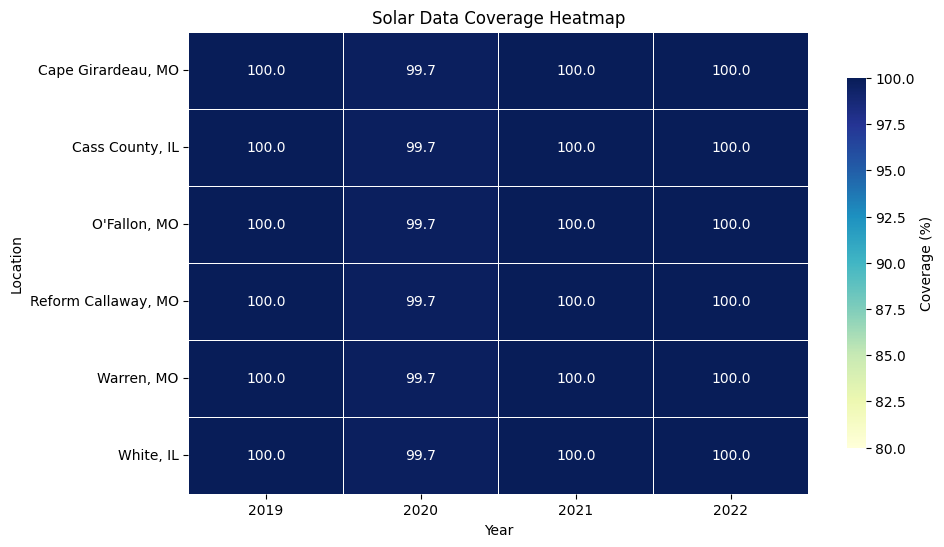

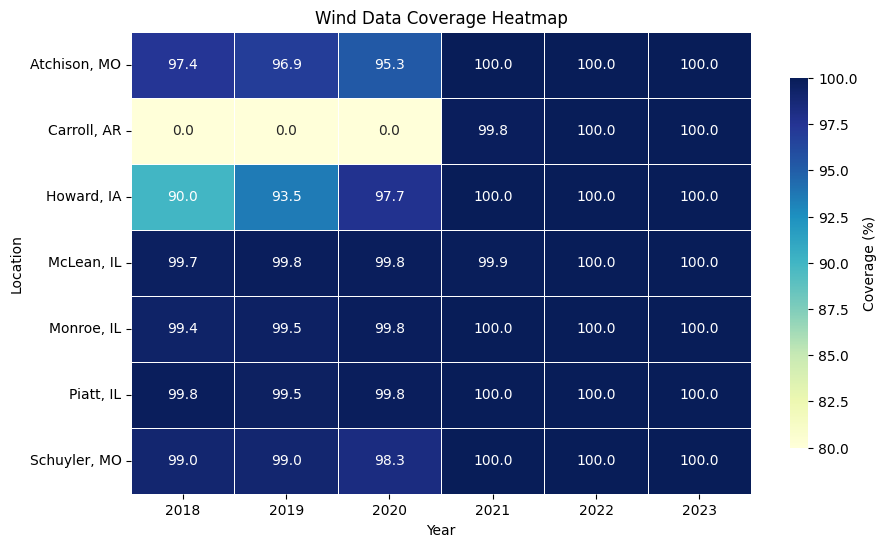

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the coverage data
coverage_df = pd.read_csv('Solar_Package/data/yearly_coverage_stats.csv')

# Pivot the table for heatmap structure
coverage_pivot = coverage_df.pivot(index='Location', columns='Year', values='CoveragePercent')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    coverage_pivot, 
    annot=True, 
    cmap="YlGnBu",     # or any other colormap
    fmt=".1f", 
    linewidths=0.5,
    vmin=80,            # set min value for colormap
    vmax=100,          # set max value for colormap
    cbar_kws={
        "label": "Coverage (%)", 
        "shrink": 0.8
    }
)
plt.title("Solar Data Coverage Heatmap")
plt.xlabel("Year")
plt.ylabel("Location")
plt.show()

# ----

# Load the coverage data
coverage_df = pd.read_csv('Wind_Package/data/yearly_coverage_stats.csv')

# Pivot the table for heatmap structure
coverage_pivot = coverage_df.pivot(index='Location', columns='Year', values='CoveragePercent')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    coverage_pivot, 
    annot=True, 
    cmap="YlGnBu",     # or any other colormap
    fmt=".1f", 
    linewidths=0.5,
    vmin=80,            # set min value for colormap
    vmax=100,          # set max value for colormap
    cbar_kws={
        "label": "Coverage (%)", 
        "shrink": 0.8
    }
)
plt.title("Wind Data Coverage Heatmap")
plt.xlabel("Year")
plt.ylabel("Location")
plt.show()

## 2. Production Diversity Comparison

This section compares how geographic diversity affects production patterns for wind vs solar.

**Key Metric:** Percentage of time when site pairs provide complementary generation (not both zero output)

**Interpretation:**
- Higher percentages = better geographic diversity
- Lower correlation indicates sites complement each other well


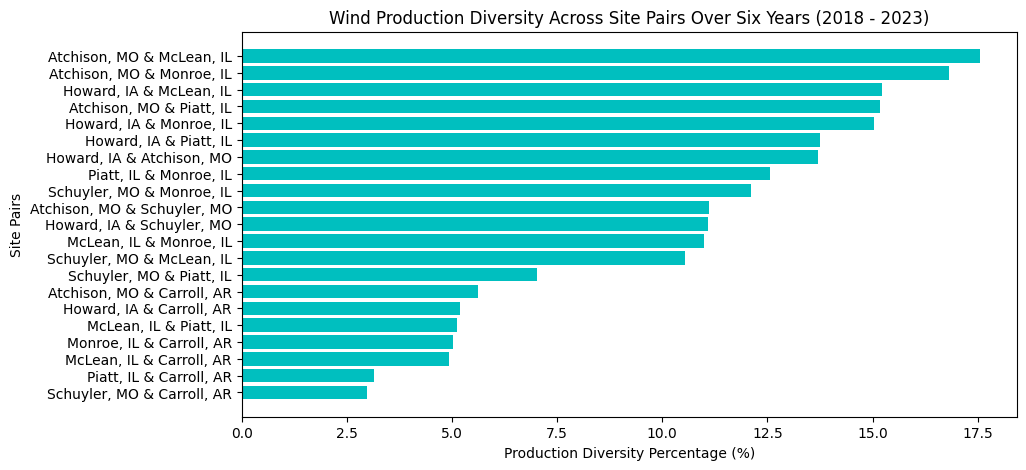

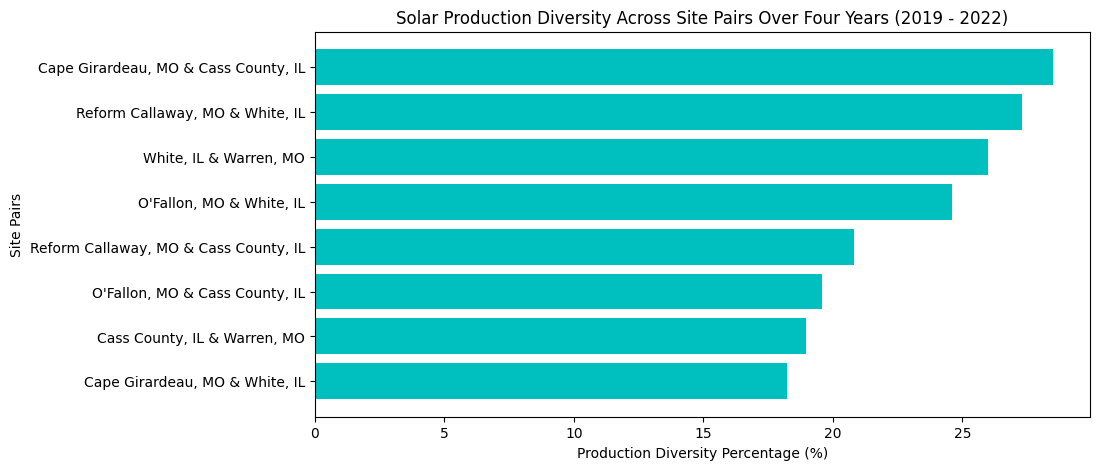

In [73]:
prodw_div_df = pd.read_csv('Wind_Package/reports/production_analysis_results.csv')

prodw_div_df = prodw_div_df.sort_values(by="Percentage", ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.barh(prodw_div_df['Pair'], prodw_div_df['Percentage'], color='c')
plt.xlabel("Production Diversity Percentage (%)")
plt.ylabel("Site Pairs")
plt.title("Wind Production Diversity Across Site Pairs Over Six Years (2018 - 2023)")
plt.gca().invert_yaxis()  # Flip to make highest percentage at the top
plt.show()


prods_div_df = pd.read_csv('Solar_Package/reports/production_analysis_results.csv')

prods_div_df = prods_div_df.sort_values(by="Percentage", ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.barh(prods_div_df['Pair'], prods_div_df['Percentage'], color='c')
plt.xlabel("Production Diversity Percentage (%)")
plt.ylabel("Site Pairs")
plt.title("Solar Production Diversity Across Site Pairs Over Four Years (2019 - 2022)")
plt.gca().invert_yaxis()  # Flip to make highest percentage at the top
plt.show()

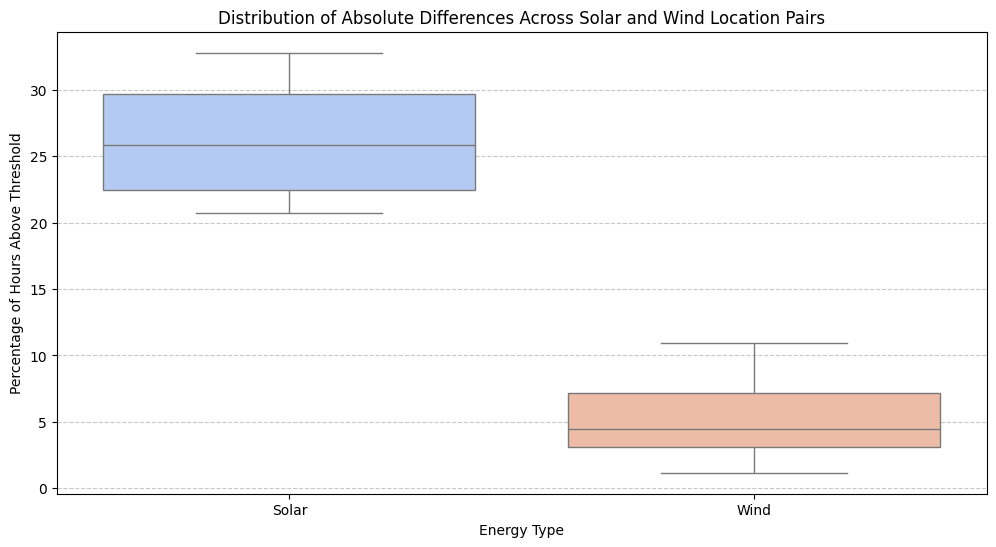

In [57]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Load Solar and Wind Absolute Difference Data
# solar_df = pd.read_csv("Solar_Package/reports/absolute_difference_analysis_results.csv")  # Replace with actual filename
# wind_df = pd.read_csv("Wind_Package/reports/absolute_difference_analysis_results.csv")    # Replace with actual filename

# # Convert Percentage Column to Numeric (removing % sign in Wind Data)
# solar_df["Percentage"] = pd.to_numeric(solar_df["Percentage"], errors="coerce")  # Solar already numeric
# wind_df["Percentage"] = wind_df["Percentage"].astype(float)  # Remove "%" and convert

# # Combine and Add Energy Type Column
# solar_df["Type"] = "Solar"
# wind_df["Type"] = "Wind"
# df = pd.concat([solar_df, wind_df])

# # Plot Boxplots
# plt.figure(figsize=(12, 6))
# sns.boxplot(x="Type", y="Percentage", data=df, hue="Type", palette="coolwarm")

# # Customize Plot
# plt.title("Distribution of Absolute Differences Across Solar and Wind Location Pairs")
# plt.xlabel("Energy Type")
# plt.ylabel("Percentage of Hours Above Threshold")
# plt.grid(axis="y", linestyle="--", alpha=0.7)

# # Show the Plot
# plt.show()

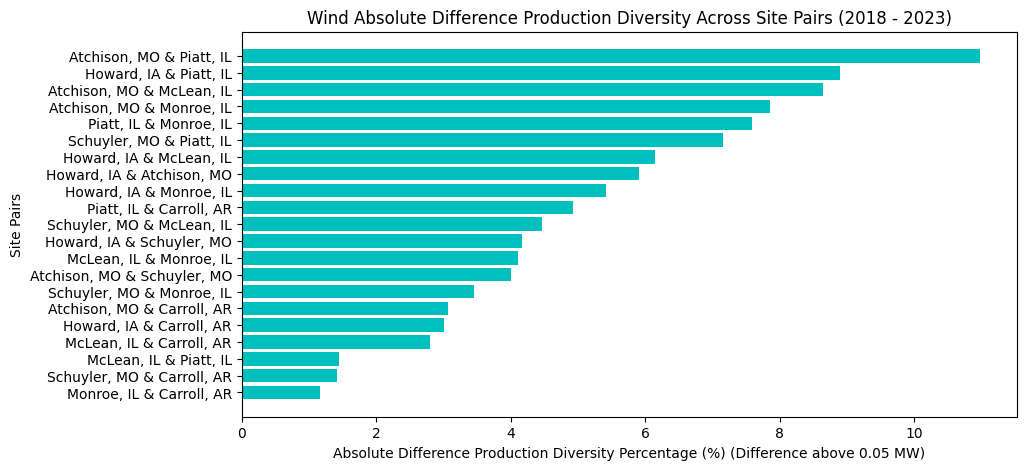

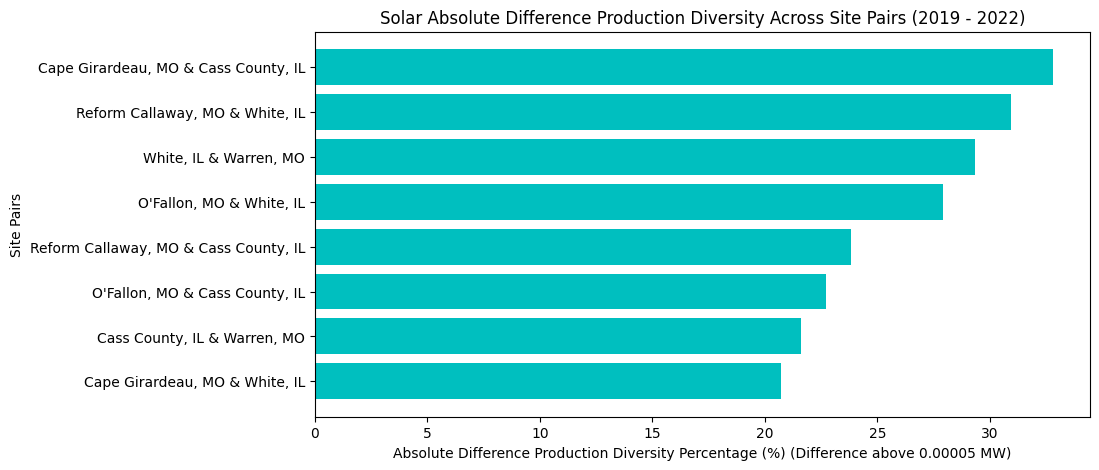

In [82]:
# Plot bar chart
plt.figure(figsize=(10, 5))
plt.barh(wind_df['Pair'], wind_df['Percentage'], color='c')
plt.xlabel("Absolute Difference Production Diversity Percentage (%) (Difference above 0.05 MW)")
plt.ylabel("Site Pairs")
plt.title("Wind Absolute Difference Production Diversity Across Site Pairs (2018 - 2023)")
plt.gca().invert_yaxis()  # Flip to make highest percentage at the top
plt.show()

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.barh(solar_df['Pair'], solar_df['Percentage'], color='c')
plt.xlabel("Absolute Difference Production Diversity Percentage (%) (Difference above 0.00005 MW)")
plt.ylabel("Site Pairs")
plt.title("Solar Absolute Difference Production Diversity Across Site Pairs (2019 - 2022)")
plt.gca().invert_yaxis()  # Flip to make highest percentage at the top
plt.show()

In [97]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Load Solar and Wind Correlation Data
# solar_corr_df = pd.read_csv("Solar_Package/reports/correlation_analysis_results.csv") 
# wind_corr_df = pd.read_csv("Wind_Package/reports/correlation_analysis_results.csv")   

# # Split Pair into Two Columns
# solar_corr_df[['Location1', 'Location2']] = solar_corr_df['Pair'].str.split(' & ', expand=True)
# wind_corr_df[['Location1', 'Location2']] = wind_corr_df['Pair'].str.split(' & ', expand=True)

# # Create a symmetric matrix by appending reversed pairs
# solar_corr_sym = pd.concat([
#     solar_corr_df[['Location1', 'Location2', 'Correlation']],
#     solar_corr_df.rename(columns={'Location1': 'Location2', 'Location2': 'Location1'})[['Location1', 'Location2', 'Correlation']]
# ])

# wind_corr_sym = pd.concat([
#     wind_corr_df[['Location1', 'Location2', 'Correlation']],
#     wind_corr_df.rename(columns={'Location1': 'Location2', 'Location2': 'Location1'})[['Location1', 'Location2', 'Correlation']]
# ])

# # Pivot Data to Get Matrix Format
# solar_corr_matrix = solar_corr_sym.pivot_table(index="Location1", columns="Location2", values="Correlation")
# wind_corr_matrix = wind_corr_sym.pivot_table(index="Location1", columns="Location2", values="Correlation")

# # Plot Solar Correlation Heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(solar_corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
# plt.title("Solar Power Output Correlation Heatmap")
# plt.xlabel("Location")
# plt.ylabel("Location")
# plt.show()

# # Plot Wind Correlation Heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(wind_corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
# plt.title("Wind Power Output Correlation Heatmap")
# plt.xlabel("Location")
# plt.ylabel("Location")
# plt.show()

In [75]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Load datasets
solar_zero_output = pd.read_csv("Solar_Package/reports/production_analysis_results.csv")
wind_zero_output = pd.read_csv("Wind_Package/reports/production_analysis_results.csv")
solar_correlation = pd.read_csv("Solar_Package/reports/correlation_analysis_results.csv")
wind_correlation = pd.read_csv("Wind_Package/reports/correlation_analysis_results.csv")
solar_absolute_diff = pd.read_csv("Solar_Package/reports/absolute_difference_analysis_results.csv")
wind_absolute_diff = pd.read_csv("Wind_Package/reports/absolute_difference_analysis_results.csv")

# ### ------------------------ ZERO OUTPUT ANALYSIS (Grouped Bar Chart) ------------------------ ###

# plt.figure(figsize=(12, 6))
# sns.barplot(x="Pair", y="Hours with Zero Output", data=wind_zero_output, color="blue", label="Wind")
# sns.barplot(x="Pair", y="Hours With Zero Output", data=solar_zero_output, color="orange", label="Solar", alpha=0.7)
# plt.xticks(rotation=90)
# plt.ylabel("Count of Zero Output Hours (%)")
# plt.xlabel("Location Pair")
# plt.title("Comparison of Zero Output Hours Across Wind and Solar Sites")
# plt.legend()
# plt.show()

# ### ------------------------ CORRELATION ANALYSIS (Clustered Bar Chart) ------------------------ ###

# plt.figure(figsize=(12, 6))
# sns.barplot(x="Pair", y="Correlation", data=wind_correlation, color="blue", label="Wind")
# sns.barplot(x="Pair", y="Correlation", data=solar_correlation, color="orange", label="Solar", alpha=0.7)
# plt.xticks(rotation=90)
# plt.ylabel("Pearson Correlation Coefficient")
# plt.xlabel("Location Pair")
# plt.title("Comparison of Correlation Coefficients Across Wind and Solar Sites")
# plt.legend()
# plt.show()

# ### ------------------------ CORRELATION VS. DISTANCE SCATTER PLOTS ------------------------ ###

# # Scatter plot for Solar Sites: Correlation vs. Distance
# plt.figure(figsize=(8, 5))
# plt.scatter(solar_correlation["Distance (mi)"], solar_correlation["Correlation"], alpha=0.6, color="orange", label="Solar")
# plt.xlabel("Distance Between Sites (miles)")
# plt.ylabel("Pearson Correlation Coefficient")
# plt.title("Solar Sites Scatter Plot: Correlation vs. Distance")
# plt.legend()
# plt.grid(True)
# plt.show()

# # Scatter plot for Wind Sites: Correlation vs. Distance
# plt.figure(figsize=(8, 5))
# plt.scatter(wind_correlation["Distance (mi)"], wind_correlation["Correlation"], alpha=0.6, color="blue", label="Wind")
# plt.xlabel("Distance Between Sites (miles)")
# plt.ylabel("Pearson Correlation Coefficient")
# plt.title("Wind Sites Scatter Plot: Correlation vs. Distance")
# plt.legend()
# plt.grid(True)
# plt.show()

### ------------------------ ABSOLUTE DIFFERENCE ANALYSIS ------------------------ ###

# # Histogram of Absolute Differences
# plt.figure(figsize=(10, 6))
# sns.histplot(solar_absolute_diff["Percentage"], bins=15, color="orange", label="Solar", alpha=0.7, kde=True)
# sns.histplot(wind_absolute_diff["Percentage"], bins=15, color="blue", label="Wind", alpha=0.5, kde=True)
# plt.xlabel("Percentage of Hours Above Threshold (%)")
# plt.xticks()
# plt.ylabel("Frequency")
# plt.title("Distribution of Significant Absolute Differences in Power Output")
# plt.legend()
# plt.show()

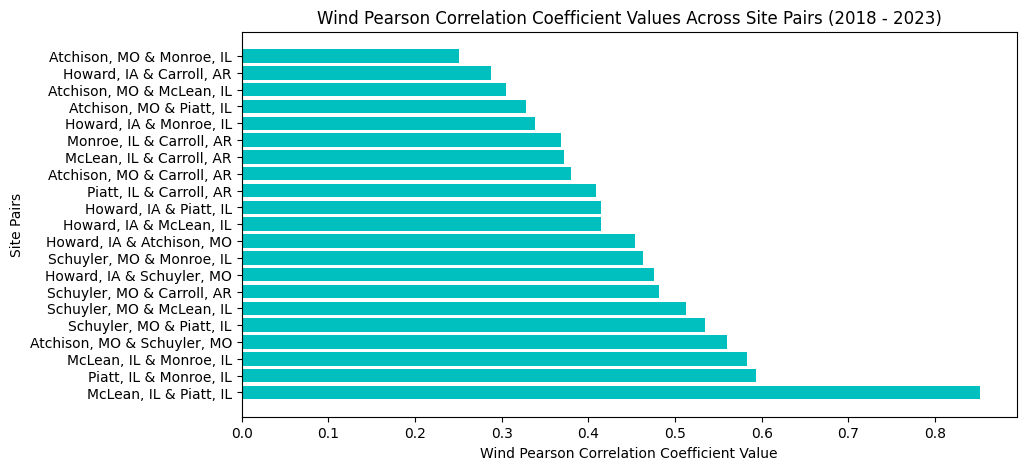

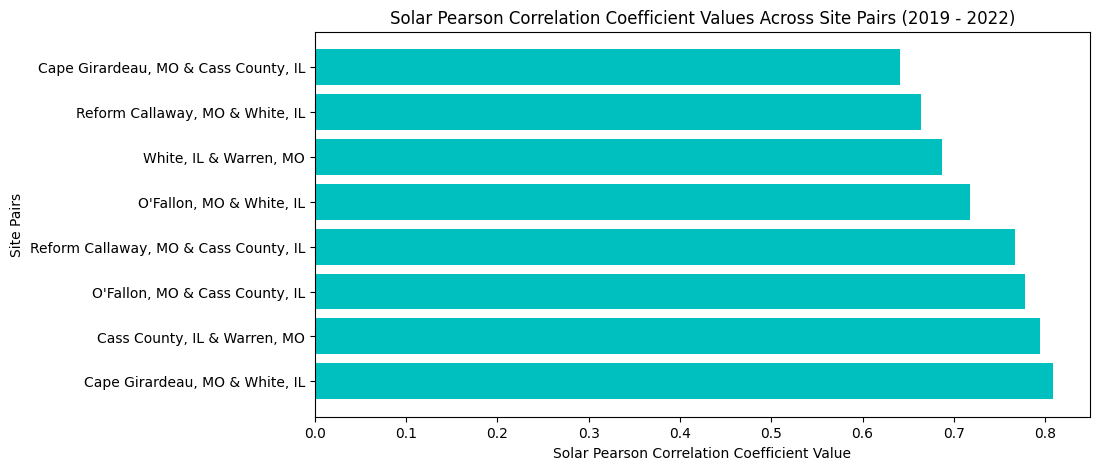

In [84]:
# Plot bar chart
plt.figure(figsize=(10, 5))
plt.barh(wind_correlation['Pair'], wind_correlation['Correlation'], color='c')
plt.xlabel("Wind Pearson Correlation Coefficient Value")
plt.ylabel("Site Pairs")
plt.title("Wind Pearson Correlation Coefficient Values Across Site Pairs (2018 - 2023)")
plt.gca().invert_yaxis()  # Flip to make highest Correlation at the top
plt.show()

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.barh(solar_correlation['Pair'], solar_correlation['Correlation'], color='c')
plt.xlabel("Solar Pearson Correlation Coefficient Value")
plt.ylabel("Site Pairs")
plt.title("Solar Pearson Correlation Coefficient Values Across Site Pairs (2019 - 2022)")
plt.gca().invert_yaxis()  # Flip to make highest Correlation at the top
plt.show()

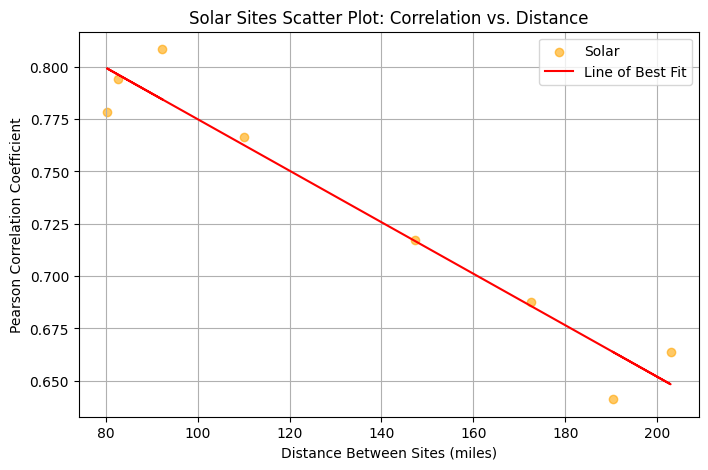

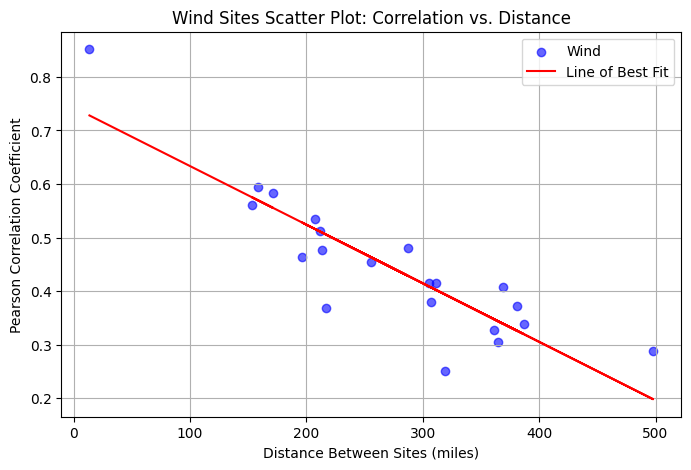

In [93]:
# ### ------------------------ CORRELATION VS. DISTANCE SCATTER PLOTS ------------------------ ###

# # Scatter plot for Solar Sites: Correlation vs. Distance
# plt.figure(figsize=(8, 5))
# plt.scatter(solar_correlation["Distance (mi)"], solar_correlation["Correlation"], alpha=0.6, color="orange", label="Solar")
# plt.xlabel("Distance Between Sites (miles)")
# plt.ylabel("Pearson Correlation Coefficient")
# plt.title("Solar Sites Scatter Plot: Correlation vs. Distance")
# plt.legend()
# plt.grid(True)
# plt.show()

# # Scatter plot for Wind Sites: Correlation vs. Distance
# plt.figure(figsize=(8, 5))
# plt.scatter(wind_correlation["Distance (mi)"], wind_correlation["Correlation"], alpha=0.6, color="blue", label="Wind")
# plt.xlabel("Distance Between Sites (miles)")
# plt.ylabel("Pearson Correlation Coefficient")
# plt.title("Wind Sites Scatter Plot: Correlation vs. Distance")
# plt.legend()
# plt.grid(True)
# plt.show()

import numpy as np

# Solar data
x_solar = solar_correlation["Distance (mi)"]
y_solar = solar_correlation["Correlation"]

# Best fit line for Solar
slope_solar, intercept_solar = np.polyfit(x_solar, y_solar, 1)
line_solar = slope_solar * x_solar + intercept_solar

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_solar, y_solar, alpha=0.6, color="orange", label="Solar")
plt.plot(x_solar, line_solar, color="red", linestyle="-", label="Line of Best Fit")
plt.xlabel("Distance Between Sites (miles)")
plt.ylabel("Pearson Correlation Coefficient")
plt.title("Solar Sites Scatter Plot: Correlation vs. Distance")
plt.legend()
plt.grid(True)
plt.show()


# Wind data
x_wind = wind_correlation["Distance (mi)"]
y_wind = wind_correlation["Correlation"]

# Best fit line for Wind
slope_wind, intercept_wind = np.polyfit(x_wind, y_wind, 1)
line_wind = slope_wind * x_wind + intercept_wind

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_wind, y_wind, alpha=0.6, color="blue", label="Wind")
plt.plot(x_wind, line_wind, color="red", linestyle="-", label="Line of Best Fit")
plt.xlabel("Distance Between Sites (miles)")
plt.ylabel("Pearson Correlation Coefficient")
plt.title("Wind Sites Scatter Plot: Correlation vs. Distance")
plt.legend()
plt.grid(True)
plt.show()


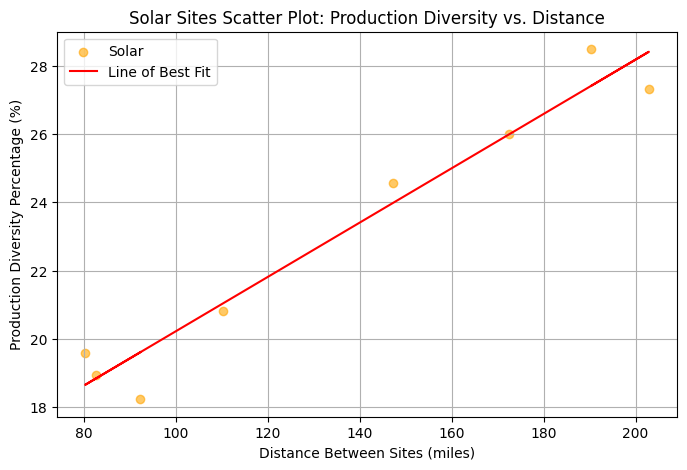

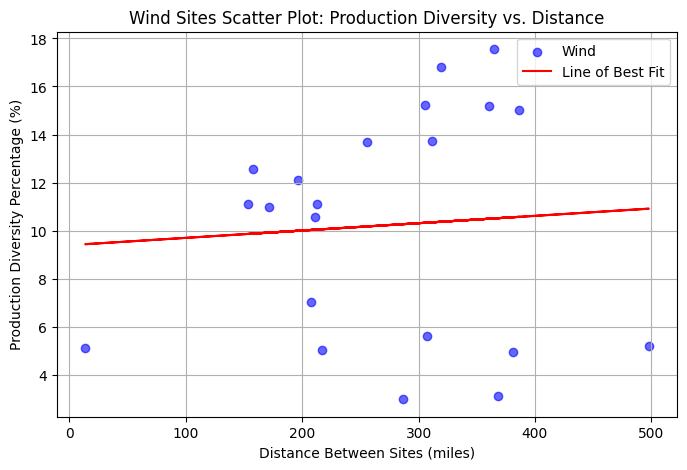

In [90]:
# Get x and y data for solar
x = prods_div_df["Distance (mi)"]
y = prods_div_df["Percentage"]

# Fit a linear regression line (degree 1 polynomial)
slope, intercept = np.polyfit(x, y, 1)

# Create the line of best fit
line = slope * x + intercept

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, color="orange", label="Solar")
plt.plot(x, line, color="red", linestyle="-", label="Line of Best Fit")  # <-- Line of best fit
plt.xlabel("Distance Between Sites (miles)")
plt.ylabel("Production Diversity Percentage (%)")
plt.title("Solar Sites Scatter Plot: Production Diversity vs. Distance")
plt.legend()
plt.grid(True)
plt.show()


# Get x and y data
x = prodw_div_df["Distance (mi)"]
y = prodw_div_df["Percentage"]

# Fit a linear regression line (degree 1 polynomial)
slope, intercept = np.polyfit(x, y, 1)

# Create the line of best fit
line = slope * x + intercept

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, color="blue", label="Wind")
plt.plot(x, line, color="red", linestyle="-", label="Line of Best Fit")  # <-- Line of best fit
plt.xlabel("Distance Between Sites (miles)")
plt.ylabel("Production Diversity Percentage (%)")
plt.title("Wind Sites Scatter Plot: Production Diversity vs. Distance")
plt.legend()
plt.grid(True)
plt.show()


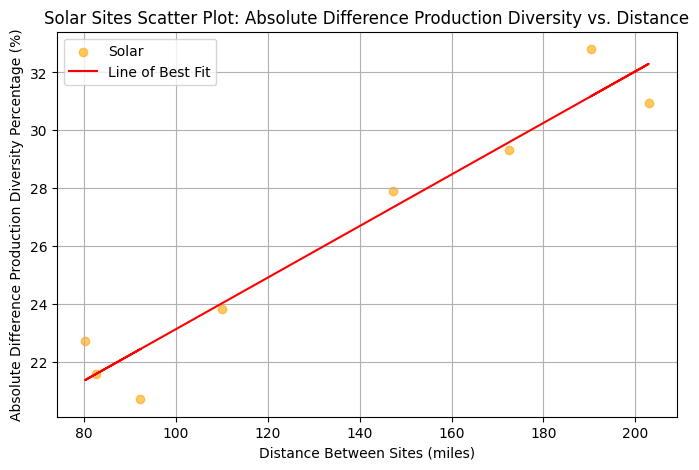

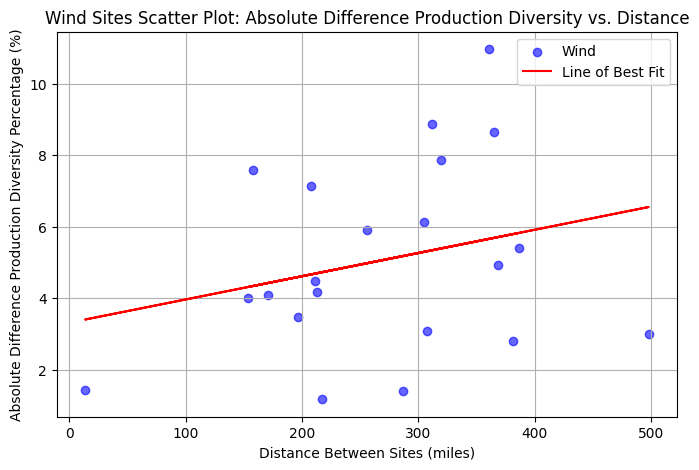

In [96]:
import numpy as np

# Solar data
x_solar = solar_df["Distance (mi)"]
y_solar = solar_df["Percentage"]

# Best fit line
slope_solar, intercept_solar = np.polyfit(x_solar, y_solar, 1)
line_solar = slope_solar * x_solar + intercept_solar

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_solar, y_solar, alpha=0.6, color="orange", label="Solar")
plt.plot(x_solar, line_solar, color="red", linestyle="-", label="Line of Best Fit")
plt.xlabel("Distance Between Sites (miles)")
plt.ylabel("Absolute Difference Production Diversity Percentage (%)")
plt.title("Solar Sites Scatter Plot: Absolute Difference Production Diversity vs. Distance")
plt.legend()
plt.grid(True)
plt.show()


# Wind data
x_wind = wind_df["Distance (mi)"]
y_wind = wind_df["Percentage"]

# Best fit line
slope_wind, intercept_wind = np.polyfit(x_wind, y_wind, 1)
line_wind = slope_wind * x_wind + intercept_wind

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_wind, y_wind, alpha=0.6, color="blue", label="Wind")
plt.plot(x_wind, line_wind, color="red", linestyle="-", label="Line of Best Fit")
plt.xlabel("Distance Between Sites (miles)")
plt.ylabel("Absolute Difference Production Diversity Percentage (%)")
plt.title("Wind Sites Scatter Plot: Absolute Difference Production Diversity vs. Distance")
plt.legend()
plt.grid(True)
plt.show()